In [12]:
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class SequentialNN(tf.keras.models.Sequential):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def predict(self, x, **kwargs):
        pred_probs = super().predict(x, **kwargs)
        rounded_probs = tf.math.round(pred_probs)
        predictions = tf.cast(rounded_probs, tf.int32).numpy()
        return predictions.flatten()

    def predict_trustee(self, x):
        pred_probs = super().predict(x)
        rounded_probs = tf.math.round(pred_probs)
        predictions = tf.cast(rounded_probs, tf.int32).numpy()
        return predictions.flatten()

In [13]:
from tensorflow.keras.models import load_model

model = load_model(
    'trained_model_updated.keras',
    custom_objects={'SequentialNN': SequentialNN}
)

In [14]:
import pandas as pd

X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test  = pd.read_csv('y_test.csv')

In [15]:
pip install trustee --no-deps

In [16]:
from trustee import ClassificationTrustee
from sklearn.metrics import classification_report

y_train_flat = y_train.values.ravel().astype(int)
y_test_flat = y_test.values.ravel().astype(int)

trustee = ClassificationTrustee(expert=model)
trustee.fit(X_train, y_train_flat, num_iter=50, num_stability_iter=10,
samples_size=0.3, verbose=True)
dt, pruned_dt, agreement, reward = trustee.explain()
dt_y_pred = dt.predict(X_test)

y_pred = model.predict_trustee(X_test)

print("Model explanation global fidelity report:")
print(classification_report(y_pred, dt_y_pred))
print("Model explanation score report:")
print(classification_report(y_test_flat, dt_y_pred))

Initializing training dataset using <SequentialNN name=sequential_nn, built=True> as expert model
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Expert model score: 0.9984799587879404
Initializing Trustee outer-loop with 10 iterations
########## Outer-loop Iteration 0/10 ##########
Initializing Trustee inner-loop with 10 iterations
########## Inner-loop Iteration 0/50 ##########
Sampling 789 points from training dataset with (2632, 2632) entries
Student model 0-0 trained with depth 1 and 2 leaves:
Student model score: 1.0
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Student model 0-0 fidelity: 1.0
########## Inner-loop Iteration 1/50 ##########
Sampling 789 points from training dataset with (2869, 2869) entries
Student model 0-1 trained with depth 1 and 2 leaves:
Student model score: 1.0
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Student model 0-1 fidelity: 1.0
########## Inner-loop Iteration 2/50 ##########
Sampling 789 points from training dataset with (3106, 3106) entries
Student model 0-2 trained with

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


Model explanation global fidelity report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       482
           1       1.00      1.00      1.00       458

    accuracy                           1.00       940
   macro avg       1.00      1.00      1.00       940
weighted avg       1.00      1.00      1.00       940

Model explanation score report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       484
           1       1.00      1.00      1.00       456

    accuracy                           1.00       940
   macro avg       1.00      1.00      1.00       940
weighted avg       1.00      1.00      1.00       940



# Visualziing the Decision Tree


In [17]:
import pydot
from sklearn.tree import export_graphviz

export_graphviz(dt, out_file='decision_tree.dot',
                filled=True, rounded=True,
                class_names=['benign', 'malicious'],
                special_characters=True)
(graph,) = pydot.graph_from_dot_file('decision_tree.dot')
graph.write_png('decision_tree.png')

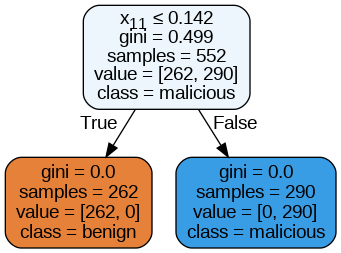

In [18]:
from IPython.display import Image, display

display(Image(filename='decision_tree.png'))

In [19]:
export_graphviz(pruned_dt, out_file='pruned_decision_tree.dot',
                filled=True, rounded=True,
                class_names=['benign', 'malicious'],
                special_characters=True)
(graph,) = pydot.graph_from_dot_file('pruned_decision_tree.dot')
graph.write_png('pruned_decision_tree.png')

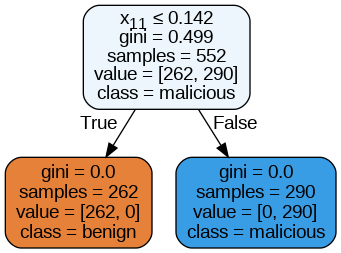

In [20]:
from IPython.display import Image, display

display(Image(filename='pruned_decision_tree.png'))

#Tricking CNN

In [42]:
import numpy as np

# Get malicious samples (label = 0)
malicious_idx = np.where(y_test == 0)[0]

# Randomly pick 100
selected_idx = np.random.choice(malicious_idx, 100, replace=False)

samples = X_test.iloc[selected_idx].copy()
y_true = y_test.iloc[selected_idx]

In [48]:
# Get average values of benign samples
benign_indices = np.where(y_test_flat == 1)[0]
benign_samples = X_test.iloc[benign_indices]

print("Benign samples - mean values per feature:")
print(benign_samples.mean())
print("\nMalicious samples - mean values per feature:")
print(samples.mean())

Benign samples - mean values per feature:
bytes_out           0.027589
num_pkts_out        0.031501
bytes_in            0.025943
num_pkts_in         0.031220
bytes_ration        0.567216
num_pkts_ration     0.571299
time                0.173516
av_pkt_size_in      0.496937
av_pkt_size_out     0.341624
var_pkt_size_in     0.507084
var_pkt_size_out    0.319074
median_in           0.562905
median_out          0.341624
mindelay            0.000000
avgdelay            0.234217
maxdelay            0.120370
dtype: float64

Malicious samples - mean values per feature:
bytes_out           0.118659
num_pkts_out        0.107540
bytes_in            0.116695
num_pkts_in         0.080832
bytes_ration        0.024684
num_pkts_ration     0.570809
time                0.383298
av_pkt_size_in      0.022520
av_pkt_size_out     0.201409
var_pkt_size_in     0.001505
var_pkt_size_out    0.046663
median_in           0.032092
median_out          0.201409
mindelay            0.000000
avgdelay            0.03523

In [50]:
modified_samples = samples.copy()
modified_samples['median_in'] = 0.5629045207705478  # benign mean

predictions_no_attack = model.predict(samples)
predictions_attack = model.predict(modified_samples)

print("Without attack:")
print(f"  Predicted as malicious (0): {np.sum(predictions_no_attack == 0)}")
print(f"  Predicted as benign (1): {np.sum(predictions_no_attack == 1)}")

print("\nWith attack (median_in = benign mean):")
print(f"  Predicted as malicious (0): {np.sum(predictions_attack == 0)}")
print(f"  Predicted as benign (1): {np.sum(predictions_attack == 1)}")
print(f"  Attack success rate: {np.sum(predictions_attack == 1)}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Without attack:
  Predicted as malicious (0): 100
  Predicted as benign (1): 0

With attack (median_in = benign mean):
  Predicted as malicious (0): 70
  Predicted as benign (1): 30
  Attack success rate: 30%


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


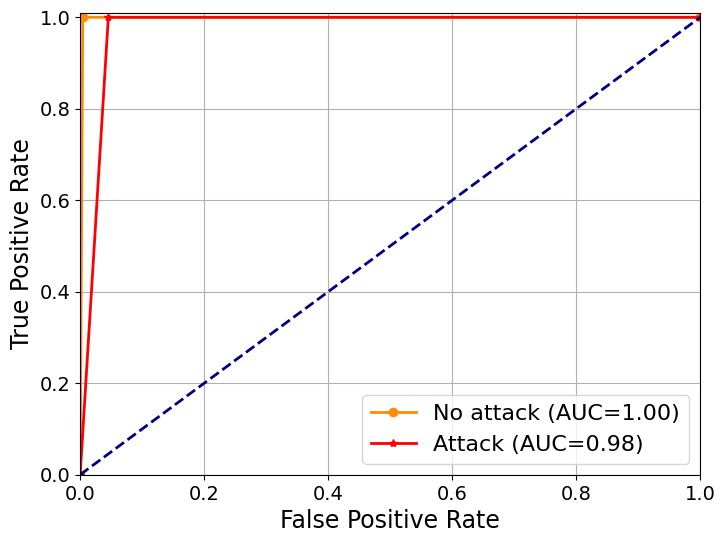

In [51]:
from sklearn.metrics import auc, roc_curve
import matplotlib.pyplot as plt

# Full test set predictions for proper ROC
full_pred_no_attack = model.predict(X_test)

X_test_attacked = X_test.copy()
X_test_attacked.iloc[malicious_sample_indices, 11] = 0.5629045207705478
full_pred_attack = model.predict(X_test_attacked)

fprn, tprn, thresholdsn = roc_curve(y_test_flat, full_pred_no_attack)
fpra, tpra, thresholdsa = roc_curve(y_test_flat, full_pred_attack)

roc_auc_n = auc(fprn, tprn)
roc_auc_a = auc(fpra, tpra)

fontSize = 17
labelSize = 14

plt.figure(figsize=(8, 6))
plt.plot(fprn, tprn, color='darkorange', lw=2, label=f'No attack (AUC={roc_auc_n:.2f})', marker='o')
plt.plot(fpra, tpra, color='red', lw=2, label=f'Attack (AUC={roc_auc_a:.2f})', marker='*')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.tick_params(axis='both', which='major', labelsize=labelSize)
plt.xlabel('False Positive Rate', fontsize=fontSize)
plt.ylabel('True Positive Rate', fontsize=fontSize)
plt.legend(loc='lower right', fontsize=fontSize-1)
plt.grid(True)
plt.savefig('roc_curve_attack.png')
plt.show()